# Final Model Evaluation

In `notebooks/reproducibility/02_` and `03_`, we pursued twin objectives: one focused on handcrafted feature extraction with Classical ML, and the other leveraging transfer learning on Deep Learning architectures.

Here, those paths converge. We will take the definitive champion from the ML track and the ultimate champion from the DL track, and pit them against each other on the unseen hold-out **Test Set**.

## 1. Final Model Champions

> Write your selection logic here for the DL model (MobileNetV2) and the ML model (Random Forest / SVM).

**Deep Learning Champion:**
- **Model:** MobileNetV2
- **Specs:** Level 1 (ImageNet), 256x256, 0.1 Dropout
- **Note:** As proven by our exhaustive learning rate grid search with extended early stopping patience, the model strictly caps at ~90% accuracy due to innate multi-label characteristics inside the dataset (i.e. leaves presenting multiple diseases concurrently while ground-truth labels force a single class).

**Classical ML Champion:**
- **Model:** Random Forest-Crafted
- **Specs:**
  - max-depth: 15
  - max features: sqrt
  - minimum sample split: 2
  - n estimators: 10
- **Note:** Our grid search tuning has led our model to an accuracy of ~76% wherein our model generally seem to struggle in fully utilizing the crafted features as demonstrated by how our data is distributed in our latent space analsysis which led us to trying deep learning alternatives.

## 2. Evaluation on the Hold-Out Test Set




In [ ]:
# Your loading logic here...

In [3]:
import wandb
import pandas as pd

api = wandb.Api()

ENTITY = "grade-descent"
PROJECT = "jute-disease-detection"

comparison_runs = {
    "Random Forest": "5ujoflpj",
    "MobileNet V2": "af60c7b9"
}

results = []

for model_name, run_id in comparison_runs.items():
    path = f"{ENTITY}/{PROJECT}/{run_id}"
    try:
        run = api.run(path)
        s = run.summary

        metrics = {
            "Model": model_name,
            "Accuracy": s.get("test_acc"),
            "Macro F1": s.get("test_f1"),
            "Precision": s.get("test_precision"),
            "Recall": s.get("test_recall")
        }
        results.append(metrics)
        print(f"Successfully fetched metrics for {model_name}")

    except Exception as e:
        print(f"Error fetching {run_id}: {e}")

df = pd.DataFrame(results)

styled_df = df.style.format({
    "Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}"
}).hide(axis='index')

display(styled_df)

Successfully fetched metrics for Random Forest
Successfully fetched metrics for MobileNet V2


Model,Accuracy,Macro F1,Precision,Recall
Random Forest,0.7639,0.7128,0.7936,0.7213
MobileNet V2,0.9139,0.9136,0.9049,0.9267


Based on the classification metrics presented above, we can see that our MobileNet V2 model has significantly outperformed our random forest model across all metrics. Based from our understanding of the feature importance and error analysis from the classical machine learning notebooks, this may be attributed as to how the deep learning approach was not constrained by the crafted features defined. To get a better understanding and intuition on this subject we proceed to the confusion matrices and the by class metrics.

### Confusion Matrices


Run the following code to setup for the confusion matrices.

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
import wandb
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix
import warnings
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

api = wandb.Api()
ENTITY = "grade-descent"
PROJECT = "jute-disease-detection"

rf_model_path = f"{ENTITY}/{PROJECT}/rf-champion:latest"
dl_artifact_path = f"{ENTITY}/{PROJECT}/run-af60c7b9-test_conf_mat_table:latest"
jute_classes = ["Cercospora", "General Damage", "Dieback", "Healthy", "Mosaic", "Stem Rot"]

def get_rf_cm_from_joblib():
    artifact = api.artifact(rf_model_path)
    model_dir = artifact.download()
    model = joblib.load(Path(model_dir) / "rf_crafted_champion.joblib")

    X_test = np.load("/content/drive/MyDrive/artifacts/features/craftedfeatureextractor_test_X.npy")
    y_test = np.load("/content/drive/MyDrive/artifacts/features/craftedfeatureextractor_test_y.npy")

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    return pd.DataFrame(cm, index=jute_classes, columns=jute_classes), y_test

def get_dl_cm_from_json(artifact_path):
    artifact = api.artifact(artifact_path)
    artifact_dir = artifact.download()
    json_file = next(Path(artifact_dir).glob("*.json"))
    with open(json_file) as f:
        raw_data = json.load(f)

    df = pd.DataFrame(raw_data["data"], columns=raw_data["columns"])
    df['Actual'] = df['Actual'].replace({"Cercospora Leaf Spot": "Cercospora"})
    df['Predicted'] = df['Predicted'].replace({"Cercospora Leaf Spot": "Cercospora"})

    val_col = "n" if "n" in df.columns else "nPredictions"
    pivot = df.groupby(['Actual', 'Predicted'])[val_col].sum().unstack().fillna(0)
    return pivot.reindex(index=jute_classes, columns=jute_classes, fill_value=0)

def get_per_class_metrics(cm_pivot):
    metrics_list = []
    total_samples = cm_pivot.values.sum()
    classes = cm_pivot.index.tolist()

    for cls in classes:
        # Binary Classification components for the specific class
        tp = cm_pivot.loc[cls, cls]
        fp = cm_pivot[cls].sum() - tp
        fn = cm_pivot.loc[cls].sum() - tp
        tn = total_samples - (tp + fp + fn)

        # Performance Formulas
        accuracy = (tp + tn) / total_samples
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        metrics_list.append({
            "Class": cls,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Support": int(tp + fn)
        })

    return pd.DataFrame(metrics_list)


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


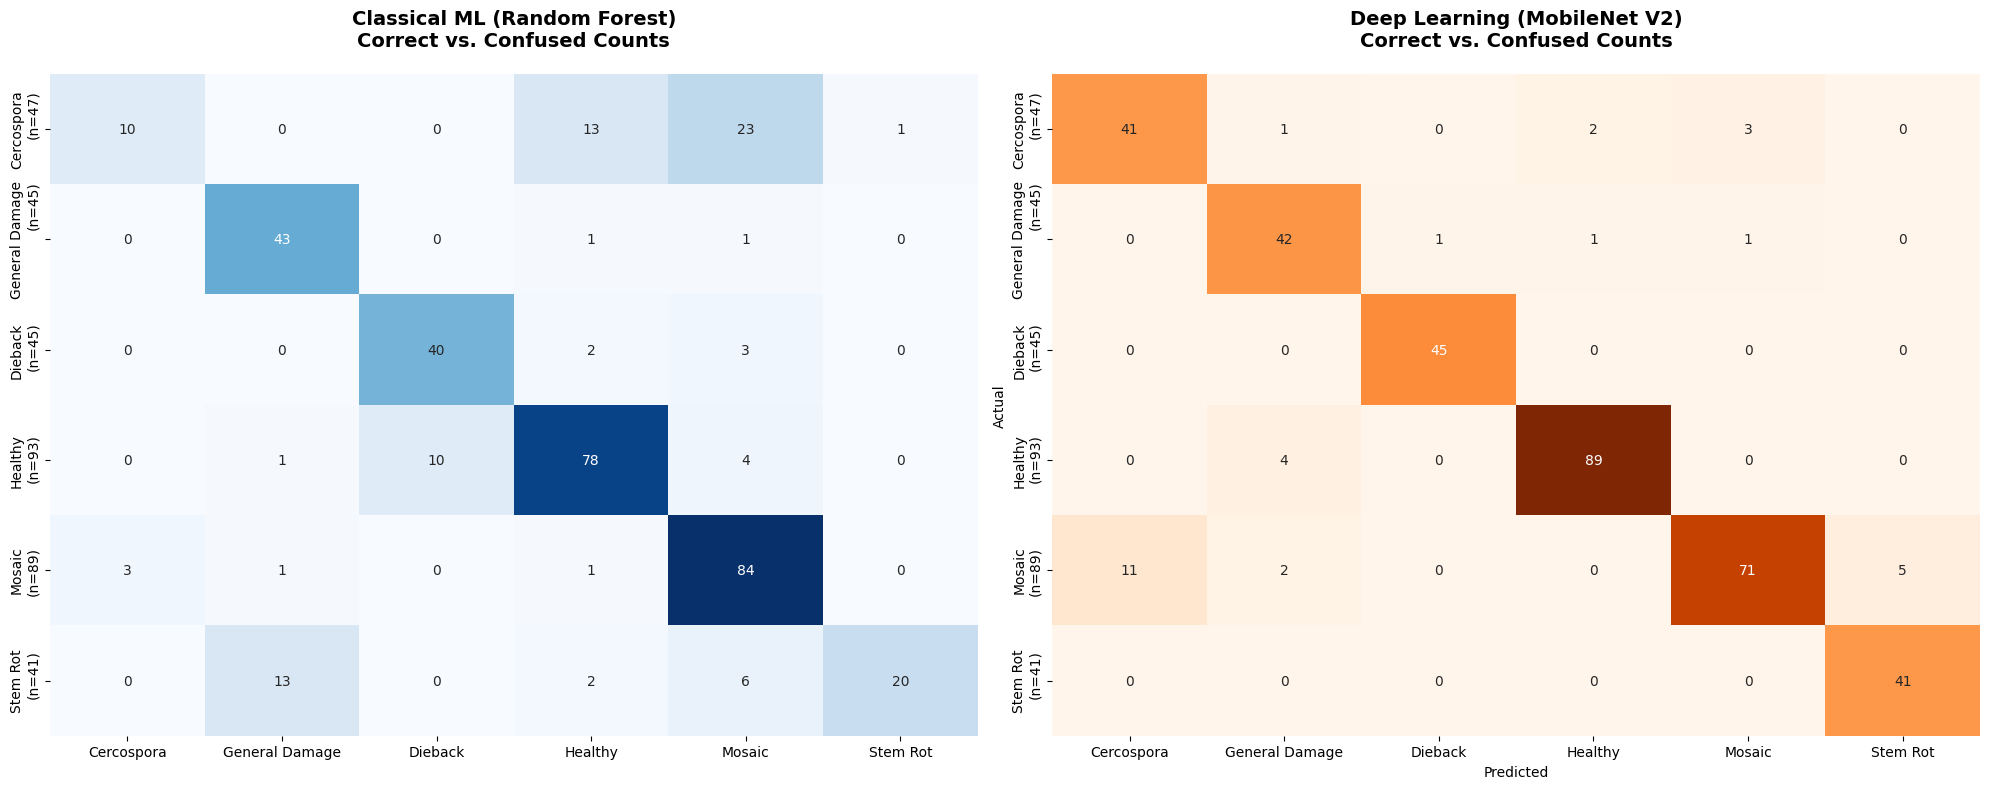


 Per-Class Performance - Champion Random Forest


Class,Accuracy,Precision,Recall,F1-Score,Support
Cercospora,0.8889,0.7692,0.2128,0.3333,47
General Damage,0.9528,0.7414,0.9556,0.8350,45
Dieback,0.9583,0.8000,0.8889,0.8421,45
Healthy,0.9056,0.8041,0.8387,0.8211,93
Mosaic,0.8833,0.6942,0.9438,0.8000,89
Stem Rot,0.9389,0.9524,0.4878,0.6452,41



 Per-Class Performance - MobileNet V2


Class,Accuracy,Precision,Recall,F1-Score,Support
Cercospora,0.9528,0.7885,0.8723,0.8283,47
General Damage,0.9722,0.8571,0.9333,0.8936,45
Dieback,0.9972,0.9783,1.0000,0.9890,45
Healthy,0.9806,0.9674,0.9570,0.9622,93
Mosaic,0.9389,0.9467,0.7978,0.8659,89
Stem Rot,0.9861,0.8913,1.0000,0.9425,41


In [6]:
cm_rf, y_test_rf_raw = get_rf_cm_from_joblib()
cm_dl = get_dl_cm_from_json(dl_artifact_path)

labels_rf = [f"{cls}\n(n={int(count)})" for cls, count in zip(jute_classes, cm_rf.sum(axis=1))]
labels_dl = [f"{cls}\n(n={int(count)})" for cls, count in zip(jute_classes, cm_dl.sum(axis=1))]

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=jute_classes, yticklabels=labels_rf, cbar=False)
axes[0].set_title("Classical ML (Random Forest)\nCorrect vs. Confused Counts",
                  fontsize=14, pad=20, fontweight='bold')

sns.heatmap(cm_dl, annot=True, fmt='g', cmap='Oranges', ax=axes[1],
            xticklabels=jute_classes, yticklabels=labels_dl, cbar=False)
axes[1].set_title("Deep Learning (MobileNet V2)\nCorrect vs. Confused Counts",
                  fontsize=14, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()



df_rf_final = get_per_class_metrics(cm_rf)
df_dl_final = get_per_class_metrics(cm_dl)

print("\n Per-Class Performance - Champion Random Forest")
styled_rf = df_rf_final.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}",
    "Recall": "{:.4f}", "F1-Score": "{:.4f}"
}).hide(axis='index')
display(styled_rf)

print("\n Per-Class Performance - MobileNet V2")
styled_dl = df_dl_final.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}",
    "Recall": "{:.4f}", "F1-Score": "{:.4f}"
}).hide(axis='index')
display(styled_dl)

We first look at the confusion matrix comparison in the figures above. At a glance, it is clear that the MobileNet V2 model has significantly reduced its errors in misclassifying the test set and has improved the correct predictions as shown in the diagonal of the confusion matrix. However we can see that `Mosaic` instances being misclassified as `Cercospora Leaf Spots` increased while `Cercospora Leaf Spots` being misclassified as `Mosaic` decreased by a noticeable amount. This suggest that our shift in attempting a deep learning alternative approach has somewhat addressed our models problem in interchanging these two classes.

Diving deeper into the comparison, we can see that the in the classification metrics for the six classes, the MobileNet V2 outperformed the tuned Random forest model across accuracy and F1-score for all classes. This further reinforces the strength that our deep learning approach had on our previous classical machine learning approach. With regards the `Cercospora` and `Mosaic` dynamic, we can see that precision and recall increase for these classes with the exception of the recall value of `Mosaic`. This suggests that our model MobileNet V2 model is still struggling in correctly identifying `Mosaic` images to some degree. From our understanding, we believe that this may be due to how the actual `Mosaic` instances share characteristics with `Cercospora` which may or may not be due to having both deseases be present at the same time.  

## 3. Deep Learning vs. Classical ML: The Final Comparison

> Summarize the head-to-head.
- **Overall Performance**: Did DL significantly outperform ML, or was it surprisingly close?
- **Cost & Efficiency**: What is the difference in latency (inference time)? Classical ML might be faster but required extensive upfront feature extraction overhead (Gabor filters, GLCM). DL operates directly on raw pixels but requires GPU acceleration for scale.
- **Interpretability**: Classical models heavily rely on explicit texture boundaries. DL allows for spatial Grad-CAM heatmapping.




### 3A: Overall Performance
The DL model was able to noticeably outperform the ML model across all four classification metrics (accuracy, precision, recall, and F1-Macro). In addition to this, the confusion matrices show a noticeable improvement in correctly classifying between classes. As mentioned earlier, the models ability to correctly distinguish between `Cercospora Leaf Spot` and `Mosaic` still prevails with the possibility being that maybe both diseases are present in the dataset used.

### 3B: Cost & Efficiency
In terms of cost and efficiency,

### 3C: Interpretability
Our two models used two distinct approaches with the tuned Random Forest using the crafted features (HSV, LBP, GLCM, and HOG) extracted from the images while our MobileNet V2 used a transfer learning approahch.

As dicsussed in the previous `Notebook 3` for classical machine learning model tuning and error analysis, the feature importance section describe how our random forest model primarily relied on Histogram of Oriented Gradients (HOG) which capture the structure and shapes present in our image.

However, two particular color channels stood out as they were identified to be among the top five most important features which are the `STD of Green Color Channel` and `Mean of Red Color Channel`. We hypothesize that these two color channels acted as the main drivers in distinguishing between classes that are characterized by an attribute of color. Such characteristics are as follows:
- `Cercospora Leaf Spots` - brown lesions
- `Mosaic` - yellow patches
- `Stem Rot` - dark brown lesions on stems


On the other hand, the deep learning approach


> explain further




## 4. Conclusion and Future Directives
Our work on jute disease image classification using classical machine learning and deep learning has allowed us to explore different strategies in creating a model that can correctly classify `Cercospora Leaf Spots`, `Dieback`, `Healthy`, `General Damage`, `Mosaic`, and `Stem Rot` in jute leaves. Our training, error analysis, and fine tuning process has determined that our MobileNet V2 model stood out among the different models utilized. The error analysis provided us with the insights that may improve our models' performance. First, we theorize that the images may have preprocessing given that our Grad-Cam Heatmap figures show that there are instances where the deep learning model primarily focuses on non-relevant subjects (i.e., leaves present in the background). Next, we observed that both learning approaches particularly struggled in classifying `Cercospora Leaf Spots` and `Mosaic`. Upon investigation of such mistaken images, we observed that there is a possibility that the leaves may be considered as having multiple symptoms of the diseases which is a direct limitation of our project as we implemented a single-label constraint. Nonetheless, this has provided us with the means on how to improve the current state of the models such as transitioning to a multi-label learning framework rather than a standard Softmax layer. Lastly, in consideration of model deployment, we are confident that the model may be integrated into edge devices such as smartphones so that Jute farmer's may utilize it to quickly identify such diseases and plan accrodingly.